In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df=pd.read_csv('C:/Users/HP/OneDrive/Desktop/DsIntern/Advertising.csv')

# Data Exploration & cleaning

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [9]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
corr = df.corr()
print(corr)


                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


# EDA (EXPLORATORY DATA ANALYSIS)

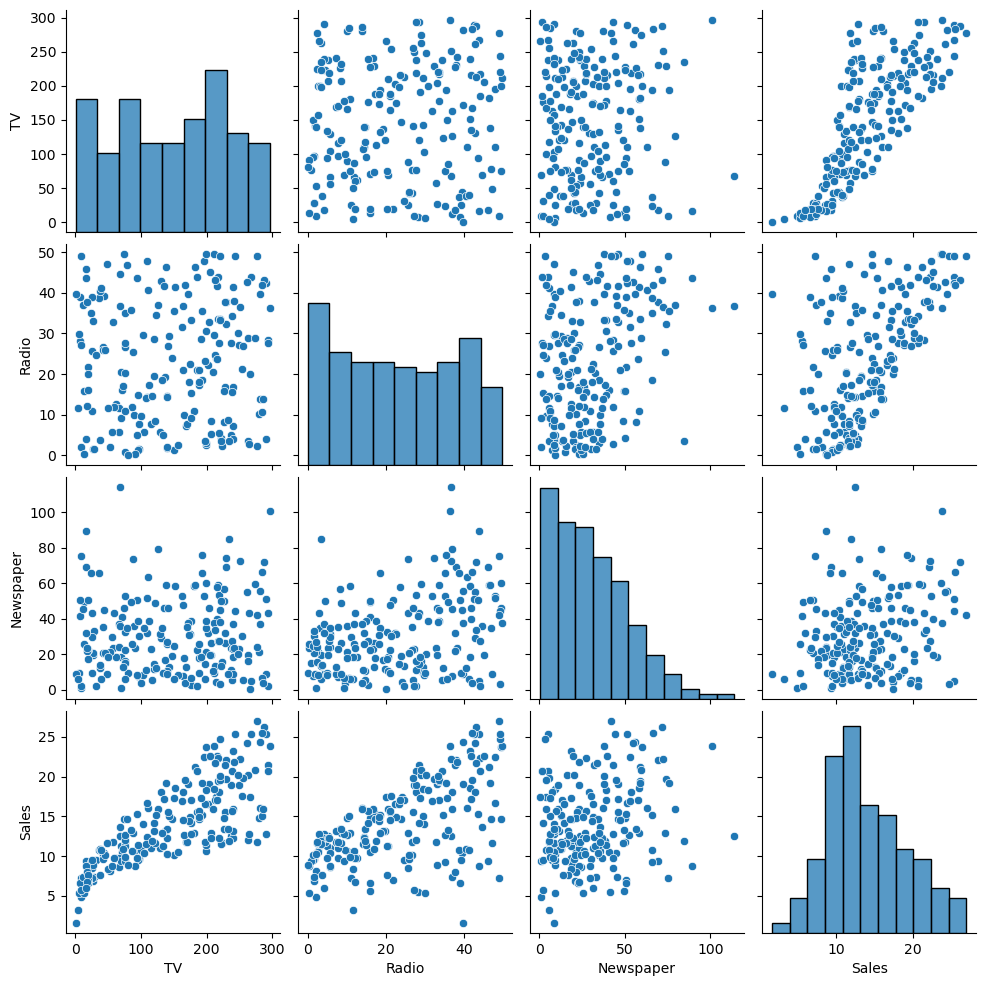

In [10]:
sns.pairplot(df)
plt.show()

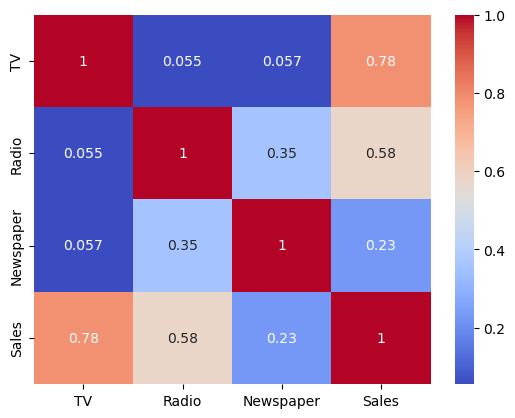

In [19]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

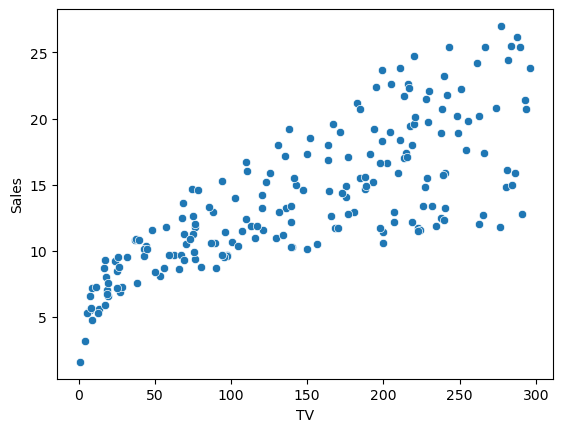

In [20]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.show()

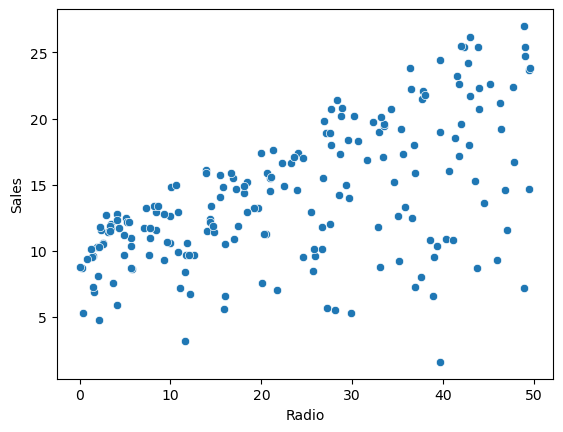

In [21]:
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.show()


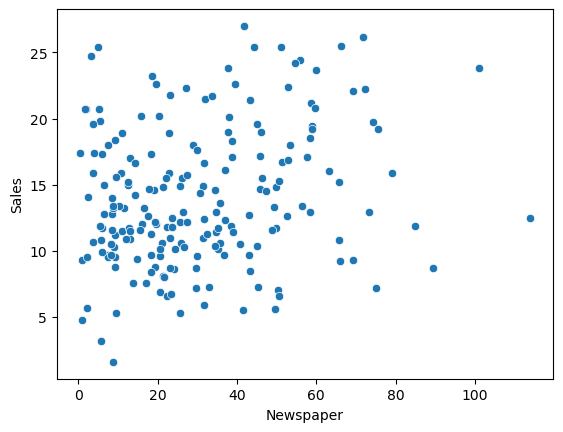

In [22]:
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.show()


In [12]:
X = df[["TV","Radio","Newspaper"]]  # input features

y = df["Sales"]   # target


# Model Selection

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

print("\nModel Training Complete")


Model Training Complete


# Prediction

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("\nMean Squared Error:",mse)

print("R2 Score:",r2)


Mean Squared Error: 3.1740973539761046
R2 Score: 0.899438024100912


In [17]:
print("\nModel Coefficients")

for name,coef in zip(X.columns,model.coef_):

    print(name,":",coef)

print("Intercept :",model.intercept_)


Model Coefficients
TV : 0.044729517468716326
Radio : 0.18919505423437655
Newspaper : 0.0027611143413671757
Intercept : 2.979067338122629


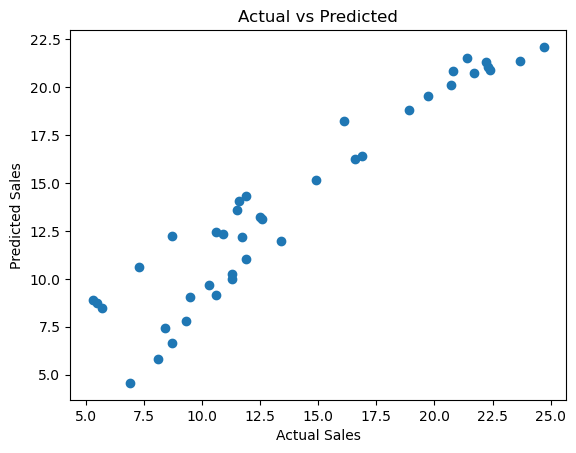

In [18]:
plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()